# Matched-k test: do the density methods beat a generic partition?

Silhouette falls as the number of clusters rises, on any data. Section 5 of the main notebook
compares each density run against a null at the same *parameter*, and the two sides then return
different cluster counts, so their silhouettes are not comparable.

This notebook fixes that. For every density run it takes the rows the method kept, counts the
clusters it found, and fits spherical KMeans on the same rows with the same k. Both partitions
then cover one row set at one granularity, so the difference between their silhouettes is a
fact about the partition.

`delta = silhouette(density) - silhouette(KMeans at the same k)`. A positive delta means the
density method found a better partition than a generic one of the same size.

This is a side test. Sample sizes are small and each size runs once.


In [1]:
import json, pathlib
import numpy as np, polars as pl, pyarrow.ipc as pa_ipc
import cupy as cp, cuml
from cuml.metrics.cluster import silhouette_score
import matplotlib.pyplot as plt

SAMPLE_SIZES  = [10_000, 20_000]
SUBSAMPLE_SEED = 67
RANDOM_SEED    = 42
PCA_VARIANCE   = 0.90
UMAP_DIMS, UMAP_N_NEIGHBORS, UMAP_MIN_DIST = 3, 30, 0.0
DBSCAN_MIN_SAMPLES = 10
N_INIT = 5

# Parameters scaled down for the smaller samples used here.
DBSCAN_EPS   = [0.5, 1.0, 2.0, 3.0]
HDBSCAN_SIZE = [25, 50, 100, 200]

EMBEDDINGS = "/datapool/analysis_data/proj-sim/embeddings/2026-08-08/embeddings_43e3b506acd198f3.arrow"
MAIN_NB    = "/home/stephen/Project-Sim/data_load_personae.ipynb"

# spherical_kmeans comes from the main notebook so the two cannot drift apart.
_main = json.load(open(MAIN_NB))
_impl = "".join([c["source"] for c in _main["cells"] if c["id"] == "spherical-kmeans-impl"][0])
_ns = {"np": np, "cp": cp, "cuml": cuml}
exec(_impl, _ns)
spherical_kmeans = _ns["spherical_kmeans"]
print("loaded spherical_kmeans from the main notebook")


loaded spherical_kmeans from the main notebook


In [2]:
with pa_ipc.open_file(EMBEDDINGS) as reader:
    _table = reader.read_all()
_col = _table["embedding"].combine_chunks()
FULL = (_col.flatten().to_numpy(zero_copy_only=False)
             .reshape(len(_col), -1).astype(np.float32, copy=False))
print(f"corpus: {FULL.shape[0]:,} rows x {FULL.shape[1]} dims")

def l2_normalize(X):
    n = np.linalg.norm(X, axis=1, keepdims=True)
    return (X / np.maximum(n, 1e-12)).astype(np.float32)

def fit_umap(X):
    return np.asarray(cuml.manifold.UMAP(
        n_components=UMAP_DIMS, n_neighbors=UMAP_N_NEIGHBORS, min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_SEED, metric="cosine").fit_transform(X))

def normalize_scale(X):
    """Divide by the median k-distance so one eps means the same thing in every space."""
    nn = cuml.neighbors.NearestNeighbors(n_neighbors=DBSCAN_MIN_SAMPLES + 1)
    nn.fit(X)
    dists, _ = nn.kneighbors(X)
    return X / float(np.median(np.asarray(dists)[:, -1]))

def column_shuffle(X, rng):
    return np.column_stack([rng.permutation(X[:, j]) for j in range(X.shape[1])]).astype(np.float32)

def cosine_silhouette(space, labels):
    ids = np.unique(labels)
    if len(ids) < 2:
        return float("nan")
    return float(silhouette_score(np.ascontiguousarray(space, dtype=np.float32),
                                  np.searchsorted(ids, labels).astype(np.int32), metric="cosine"))


corpus: 317,945 rows x 384 dims


In [3]:
def matched_k_rows(density_labels, score_space):
    """Compare a density partition with spherical KMeans on the same rows at the same k.

    Noise is dropped first, so both partitions cover one row set. KMeans is then given the
    cluster count the density method chose, so neither side gains from a coarser split.
    """
    keep = density_labels != -1
    if keep.sum() < 10:
        return None
    lbl  = density_labels[keep]
    k    = len(np.unique(lbl))
    if k < 2:
        return None
    sub  = score_space[keep]
    sil_density = cosine_silhouette(sub, lbl)
    km, _c, _o  = spherical_kmeans(l2_normalize(sub), k, n_init=N_INIT, max_iter=300,
                                   tol=1e-6, random_state=RANDOM_SEED)
    sil_kmeans  = cosine_silhouette(sub, km)
    return dict(k=k, rows=int(keep.sum()), noise=float((~keep).mean()) * 100,
                sil_density=sil_density, sil_kmeans=sil_kmeans,
                delta=sil_density - sil_kmeans)

def density_runs(umap_space):
    g = cp.asarray(umap_space, dtype=cp.float32)
    out = {}
    for eps in DBSCAN_EPS:
        out[("DBSCAN", eps)] = cuml.cluster.DBSCAN(
            eps=eps, min_samples=DBSCAN_MIN_SAMPLES, metric="euclidean").fit_predict(g).get()
    for mcs in HDBSCAN_SIZE:
        out[("HDBSCAN", mcs)] = cuml.cluster.HDBSCAN(
            min_cluster_size=mcs, metric="euclidean").fit_predict(g).get()
    del g; cp.get_default_memory_pool().free_all_blocks()
    return out

results = []
rng = np.random.default_rng(RANDOM_SEED)

for n in SAMPLE_SIZES:
    idx = (pl.DataFrame({"_": np.zeros(len(FULL), dtype=np.int8)}).with_row_index("_idx")
             .sample(n=n, seed=SUBSAMPLE_SEED)["_idx"].to_numpy())
    raw = FULL[idx]
    probe  = cuml.PCA(n_components=raw.shape[1]).fit(raw)
    ncomp  = int(np.searchsorted(np.cumsum(np.asarray(probe.explained_variance_ratio_)),
                                 PCA_VARIANCE)) + 1
    del probe
    pca = np.asarray(cuml.PCA(n_components=ncomp).fit_transform(raw))

    spaces = {f"PCA{ncomp}": pca, "384": raw}
    for space_name, X in spaces.items():
        for condition, M in (("real", X), ("column shuffle", column_shuffle(X, rng))):
            runs = density_runs(normalize_scale(fit_umap(M)))
            for (method, param), labels in runs.items():
                row = matched_k_rows(labels, M)
                if row is None:
                    continue
                results.append(dict(n=n, space=space_name, condition=condition,
                                    method=method, param=param, **row))
    print(f"  n={n:,} done ({ncomp} PCA dims)", flush=True)

results = pl.DataFrame(results)
print(f"\n{len(results)} configurations produced at least 2 clusters")


  n=10,000 done (182 PCA dims)


  n=20,000 done (183 PCA dims)



51 configurations produced at least 2 clusters


In [4]:
_real = results.filter(pl.col("condition") == "real").sort(["n", "method", "space", "param"])
print(f"{'n':>7s}{'method':>9s}{'space':>8s}{'param':>7s}{'k':>6s}{'rows':>8s}"
      f"{'sil density':>13s}{'sil kmeans@k':>14s}{'delta':>9s}")
for r in _real.iter_rows(named=True):
    print(f"{r['n']:>7,}{r['method']:>9s}{r['space']:>8s}{str(r['param']):>7s}{r['k']:>6d}"
          f"{r['rows']:>8,}{r['sil_density']:>13.3f}{r['sil_kmeans']:>14.3f}{r['delta']:>+9.3f}")

print("\ndelta by method, real data only:")
for method in ("DBSCAN", "HDBSCAN"):
    d = _real.filter(pl.col("method") == method)["delta"].to_numpy()
    print(f"  {method:8s} n={len(d):>2d}  median {np.median(d):+.3f}  "
          f"range {d.min():+.3f} to {d.max():+.3f}  |  positive in {int((d > 0).sum())} of {len(d)}")


      n   method   space  param     k    rows  sil density  sil kmeans@k    delta
 10,000   DBSCAN     384    0.5    93   2,550        0.257         0.236   +0.021
 10,000   DBSCAN     384    1.0   105   7,224       -0.001         0.082   -0.083
 10,000   DBSCAN     384    2.0    29   9,915       -0.126         0.044   -0.170
 10,000   DBSCAN     384    3.0    20   9,979       -0.124         0.039   -0.163
 10,000   DBSCAN  PCA182    0.5    95   2,606        0.260         0.241   +0.018
 10,000   DBSCAN  PCA182    1.0    92   6,927        0.047         0.107   -0.060
 10,000   DBSCAN  PCA182    2.0    22   9,878       -0.136         0.068   -0.204
 10,000   DBSCAN  PCA182    3.0    14   9,950       -0.124         0.066   -0.190
 10,000  HDBSCAN     384   25.0    38   4,597        0.120         0.126   -0.006
 10,000  HDBSCAN     384   50.0     5   9,889       -0.085         0.052   -0.137
 10,000  HDBSCAN     384  100.0     2  10,000       -0.037         0.063   -0.100
 10,000  HDBSCAN

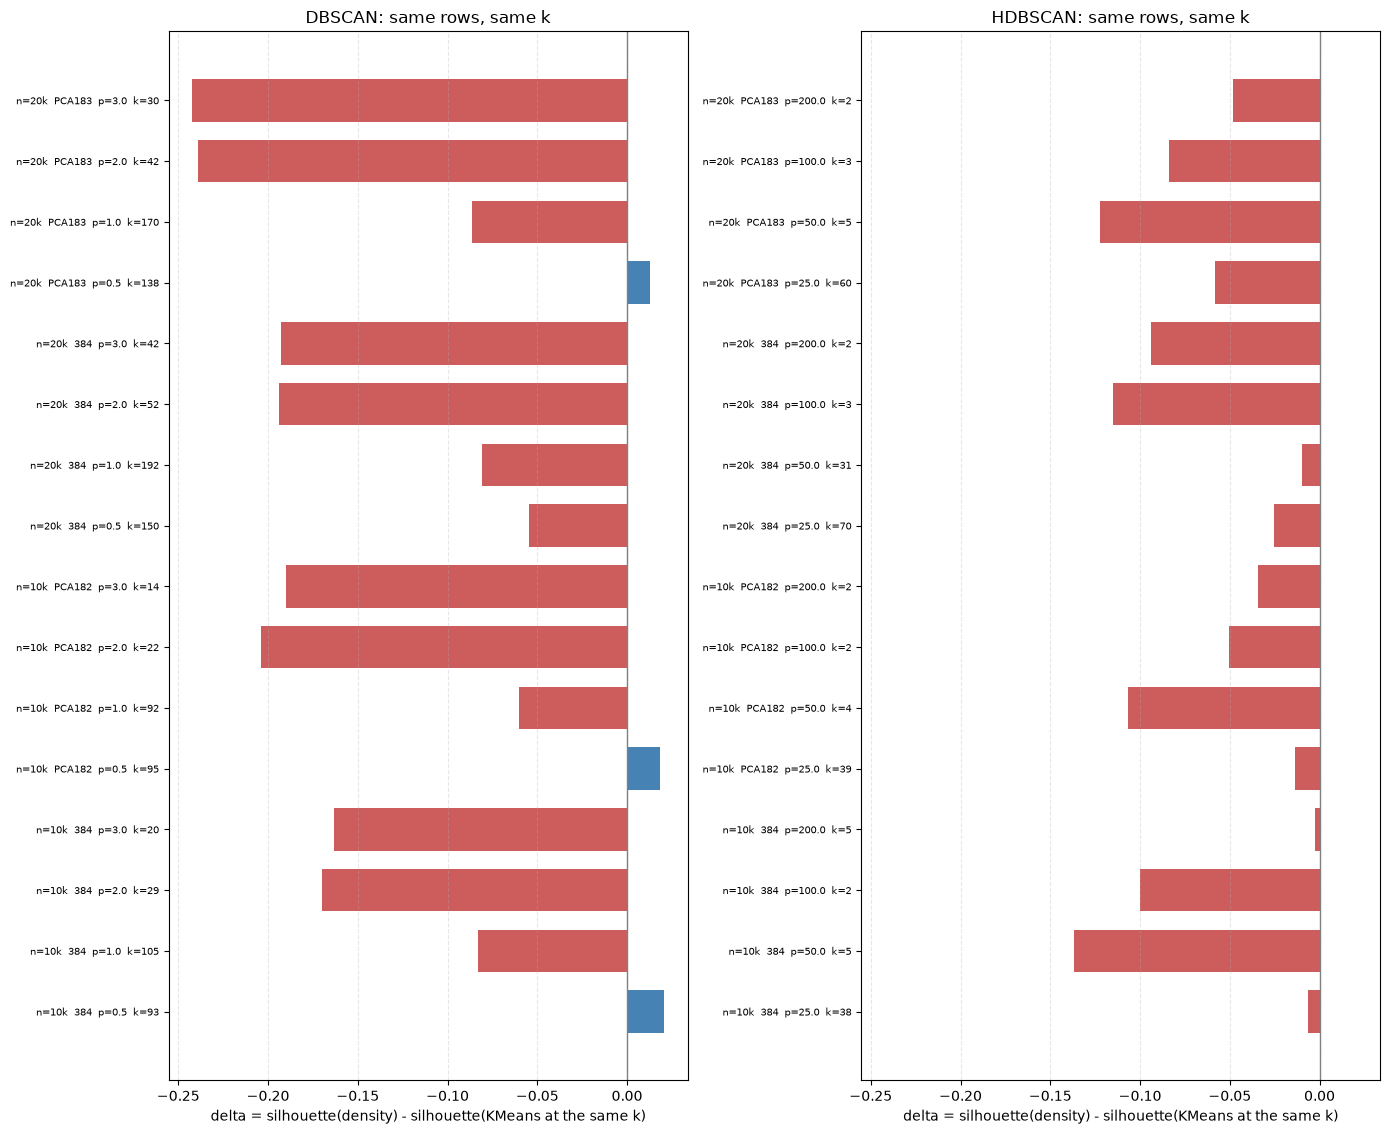

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, max(3.5, 0.32 * len(_real) + 1.2)), sharex=True)
for ax, method in zip(axes, ("DBSCAN", "HDBSCAN")):
    sub = _real.filter(pl.col("method") == method)
    labels = [f"n={r['n']//1000}k  {r['space']}  p={r['param']}  k={r['k']}"
              for r in sub.iter_rows(named=True)]
    deltas = sub["delta"].to_numpy()
    y = np.arange(len(deltas))
    ax.barh(y, deltas, height=0.7,
            color=["steelblue" if d > 0 else "indianred" for d in deltas])
    ax.set_yticks(y); ax.set_yticklabels(labels, fontsize=7)
    ax.axvline(0, color="grey", linewidth=1)
    ax.set_xlabel("delta = silhouette(density) - silhouette(KMeans at the same k)")
    ax.set_title(f"{method}: same rows, same k")
    ax.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout(); plt.show()


## Reading this

`delta > 0` means the density partition separates the kept rows better than spherical KMeans
does at the same cluster count. `delta < 0` means a generic partition of the same size does
better, and the density method earns its silhouette from dropping rows as noise rather than
from finding a better split.

The `column shuffle` rows in `results` apply the same test to data with no clusters. They are
kept for reference and are not plotted.
